In [ ]:
import pathlib

In [ ]:
import marimo as mo
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.compute as pc
import pyarrow.dataset as ds
import requests
from scipy import stats as sps
import seaborn as sns
from teeplot import teeplot as tp
from watermark import watermark

In [ ]:
mo.md(
    f"""
```Text
{watermark(
    current_date=True,
    iso8601=True,
    machine=True,
    updated=True,
    python=True,
    iversions=True,
    globals_=globals(),
)}
```
"""
)

```Text
Last updated: 2026-08-30T15:52:51.131631+00:00

Python implementation: CPython
Python version       : 3.10.12
IPython version      : 7.31.1

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.8.0-1064-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit

marimo    : 0.23.2
pyarrow   : 16.1.0
teeplot   : 1.4.2
pandas    : 2.2.3
numpy     : 2.1.2
seaborn   : 0.13.2
requests  : 2.34.2
scipy     : 1.14.1
matplotlib: 3.10.7

```

## Data

Load the per-replicate Hamming-weight **end-state** table for the
4-site mutation-rate sweep, combining two complementary slurm jobs
(both driven by notebook `bindle/2026-05-20-founder.py`, fixing
`N_SITES=4` and `POP_SIZE=1,000,000` on CPU, engine=numpy) that
together span the swept range:

- **deep / low-rate** sweep
  (`slurm/2026-08-26/2026-08-26-4site-mutation-sweep.sh`, OSF
  https://osf.io/96r2v): `MUTATION_RATE` from `1e-5` down to
  `3e-11` (~2 points per decade, 12 conditions planned), 25
  replicates per condition (300 planned), **`N_STEPS=150,000`**.
- **wide / high-rate** sweep
  (`slurm/2026-08-29/2026-08-29-4site-mutation-sweep.sh`, OSF
  https://osf.io/m6hzn): `MUTATION_RATE` from `1e-1` down to
  `3e-6` (~2 points per decade, 10 conditions), 200 replicates per
  condition (2000 planned), **`N_STEPS=5,000`** (dynamics saturate
  quickly at these higher rates, so a much shorter run suffices).

The two jobs are designed to abut at `1e-5`/`3e-6` with no overlap,
and in this data snapshot they don't actually overlap (the deep
sweep hasn't yet produced replicates at those two shared rungs) ---
but if it later does, watch the `mutation_rate x n_steps x
replicate counts` diagnostic printed below: replicates sharing a
`mutation_rate` but differing `n_steps` come from different
equilibration depths and shouldn't be treated as directly
comparable.

The deep sweep was still in flight when this notebook was written:
not every planned condition has completed replicates yet, and
completed conditions can have far fewer than 25 replicates apiece.
The wide sweep is essentially complete (200 replicates at every
condition except `3e-4`, which has 180). Treat the deep sweep's
confidence intervals as provisional accordingly (they should
tighten, and any missing conditions fill in, as the sweep
continues and its OSF file is refreshed).

Unlike the smaller companion sweeps, both OSF files back this
notebook as **full per-step trajectory tables** (one row per
`(replicate_uid, Step, hw)`) rather than pre-filtered end-state
exports, so loading either wholesale with `pandas` risks
exhausting memory. Instead, each file's final-step filter
(`Step == max(Step)`, computed per file since `N_STEPS` differs
between them) is pushed down through `pyarrow.dataset` before
materializing to `pandas` and concatenating, since every completed
replicate is recorded densely for every step (no checkpointing).

Both OSF files are downloaded with `requests` and cached at
`/tmp/<slug>` so re-runs hit the local copies.

In [ ]:
# CLI args. Defaults pull the two 4-site mutation-sweep hw parquets
# that back this notebook: the deep low-rate sweep (OSF
# https://osf.io/96r2v) and the wide high-rate sweep (OSF
# https://osf.io/m6hzn) --- see the Data section above.
_args = mo.cli_args()
OSF_SLUG_DEEP = str(_args.get("osf-slug-deep") or "96r2v")
OSF_URL_DEEP = str(
    _args.get("osf-url-deep")
    or f"https://osf.io/{OSF_SLUG_DEEP}/download",
)
OSF_SLUG_WIDE = str(_args.get("osf-slug-wide") or "m6hzn")
OSF_URL_WIDE = str(
    _args.get("osf-url-wide")
    or f"https://osf.io/{OSF_SLUG_WIDE}/download",
)
print(f"args: OSF_SLUG_DEEP={OSF_SLUG_DEEP} OSF_URL_DEEP={OSF_URL_DEEP}")
print(f"args: OSF_SLUG_WIDE={OSF_SLUG_WIDE} OSF_URL_WIDE={OSF_URL_WIDE}")

args: OSF_SLUG_DEEP=96r2v OSF_URL_DEEP=https://osf.io/96r2v/download
args: OSF_SLUG_WIDE=m6hzn OSF_URL_WIDE=https://osf.io/m6hzn/download


In [ ]:
def _download(slug, url):
    cache_path = pathlib.Path("/tmp") / slug
    if not cache_path.exists():
        print(f"downloading {url} -> {cache_path}")
        resp = requests.get(url, allow_redirects=True, timeout=300)
        resp.raise_for_status()
        cache_path.write_bytes(resp.content)
    else:
        print(f"reusing cached {cache_path}")
    print(f"size: {cache_path.stat().st_size} bytes")
    return cache_path

cache_path_deep = _download(OSF_SLUG_DEEP, OSF_URL_DEEP)
cache_path_wide = _download(OSF_SLUG_WIDE, OSF_URL_WIDE)

downloading https://osf.io/96r2v/download -> /tmp/96r2v
size: 249699504 bytes
downloading https://osf.io/m6hzn/download -> /tmp/m6hzn
size: 257102274 bytes


In [ ]:
def _load_final_step(cache_path):
    # Each parquet is the full per-step trajectory table for its
    # sweep, so avoid pd.read_parquet(cache_path) --- loading every
    # step of every replicate into pandas is enough on its own to
    # exhaust memory on a typical runner. Every completed replicate
    # is recorded densely for every step (no checkpointing), so
    # pushing a Step == max(Step) filter down through pyarrow
    # before converting to pandas recovers exactly the end-state
    # rows at a fraction of the memory cost. max(Step) is computed
    # per file since N_STEPS differs between the deep and wide
    # sweeps.
    _dataset = ds.dataset(cache_path, format="parquet")
    _max_step = pc.max(
        _dataset.to_table(columns=["Step"])["Step"],
    ).as_py()
    return _dataset.to_table(
        filter=(pc.field("Step") == _max_step),
        columns=[
            "hw",
            "n_cases",
            "replicate_uid",
            "mutation_rate",
            "n_sites",
            "n_steps",
        ],
    ).to_pandas()

hw_df = pd.concat(
    [
        _load_final_step(cache_path_deep),
        _load_final_step(cache_path_wide),
    ],
    ignore_index=True,
)
print(f"loaded hw end-state dataframe: {hw_df.shape}")
print(
    "mutation_rate x n_steps x replicate counts:\n"
    + str(
        hw_df.groupby(["mutation_rate", "n_steps"])[
            "replicate_uid"
        ].nunique(),
    ),
)

loaded hw end-state dataframe: (10400, 6)
mutation_rate x n_steps x replicate counts:
mutation_rate  n_steps
3.000000e-11   150000      11
1.000000e-10   150000      10
3.000000e-10   150000      13
1.000000e-09   150000      10
3.000000e-09   150000      12
                         ... 
1.000000e-03   5000       200
3.000000e-03   5000       200
1.000000e-02   5000       200
3.000000e-02   5000       200
1.000000e-01   5000       200
Name: replicate_uid, Length: 19, dtype: int64


## Fixation Outcome per Replicate

For each replicate, identify the **dominant Hamming-weight class**
at its final simulation step by case count (`n_cases`) --- the
Hamming-weight bin that has "fixed" as the most-populous strain
cluster at end-state, following the coarse strain identifier used
in the founder-convergence analyses.

With `N_SITES=4` there are five Hamming-weight classes drawn from
the sixteen possible genomes:

- **founder strain (0000/1111)**: Hamming weights `0` and `4`,
  i.e. the all-zero founder/wildtype genome and its bitwise
  complement (`hw in {0, 4}`, 2 of the 16 genomes).
- **HW 1/3 complements**: Hamming weights `1` and `3`, the one-
  and three-mutation classes that are bitwise complements of one
  another (`hw in {1, 3}`, 8 of the 16 genomes).
- **HW 2 self-complementary**: Hamming weight `2`, the
  two-mutation class that is its own bitwise complement (`hw == 2`,
  the remaining 6 of the 16 genomes).

We classify each replicate's end-state into one of these three
categories, then ask how the **fixation probability of each
class** depends on the swept `mutation_rate`. Splitting HW 1/3 from
HW 2 (rather than lumping all of `hw in {1, 2, 3}` together, as the
2-/3-site companion notebooks do) matters here because the two
classes carry different genome counts (8 vs. 6 of 16) and thus
different chance baselines.

In [ ]:
_n_sites = int(hw_df["n_sites"].iloc[0])

# hw_df already holds one row per (replicate_uid, hw) at each
# replicate's final step (filtered upstream in load_data), so the
# dominant Hamming-weight class per replicate is just the hw with
# the largest n_cases.
_dom_idx = hw_df.groupby("replicate_uid")["n_cases"].idxmax()
outcome_df = hw_df.loc[
    _dom_idx,
    ["replicate_uid", "mutation_rate", "hw"],
].copy()

# Founder strain (0000/1111) == extreme Hamming weights {0, N_SITES};
# HW 2 == the self-complementary middle weight (N_SITES / 2); the
# remaining weights are the HW 1/3 complement pair.
outcome_df["group"] = outcome_df["hw"].map(
    lambda _hw: "founder (0000/1111)"
    if _hw in (0, _n_sites)
    else "HW 2 (self-complementary)"
    if _hw == _n_sites // 2
    else "HW 1/3 (complements)",
)
print(f"outcome frame: {outcome_df.shape}")
print(
    "dominant hw class counts:\n"
    + str(outcome_df["hw"].value_counts().sort_index()),
)
print(
    "group counts:\n" + str(outcome_df["group"].value_counts()),
)

outcome frame: (2080, 4)
dominant hw class counts:
hw
0     270
1     130
2    1260
3     134
4     286
Name: count, dtype: int64
group counts:
group
HW 2 (self-complementary)    1260
founder (0000/1111)           556
HW 1/3 (complements)          264
Name: count, dtype: int64


## Exact (Clopper-Pearson) 95% Confidence Intervals

Each replicate's dominant-class label is one of three mutually
exclusive, collectively exhaustive outcomes, so for each
`mutation_rate` the "class X fixes vs. it doesn't" indicator is a
Bernoulli trial per replicate and the per-condition fraction is a
**binomial proportion**. We summarize each of the three group
proportions independently with the **exact Clopper-Pearson
interval** via `scipy.stats.binomtest(k, n).proportion_ci(
method="exact")` --- an exact estimator CI inverted from the
binomial CDF, **not** a bootstrap.
Per-condition replicate counts in this sweep snapshot are uneven
and can be as low as single digits (vs. the planned 25), so expect
some of these intervals --- especially at the sparser conditions
--- to be wide.

In [ ]:
_groups = [
    "founder (0000/1111)",
    "HW 1/3 (complements)",
    "HW 2 (self-complementary)",
]
_rows = []
for _mr, _sub in outcome_df.groupby("mutation_rate"):
    _n = len(_sub)
    _counts = _sub["group"].value_counts()
    for _group in _groups:
        _k = int(_counts.get(_group, 0))
        _ci = sps.binomtest(_k, _n).proportion_ci(
            confidence_level=0.95,
            method="exact",
        )
        _rows.append(
            {
                "mutation_rate": float(_mr),
                "group": _group,
                "n_fixed": _k,
                "n_total": _n,
                "p": _k / _n,
                "ci_low": float(_ci.low),
                "ci_high": float(_ci.high),
            },
        )

summary_df = (
    pd.DataFrame(_rows)
    .sort_values(
        ["group", "mutation_rate"],
    )
    .reset_index(drop=True)
)
print(summary_df.to_string(index=False))

 mutation_rate                     group  n_fixed  n_total        p   ci_low  ci_high
  3.000000e-11      HW 1/3 (complements)        2       11 0.181818 0.022831 0.517756
  1.000000e-10      HW 1/3 (complements)        4       10 0.400000 0.121552 0.737622
  3.000000e-10      HW 1/3 (complements)        7       13 0.538462 0.251345 0.807768
  1.000000e-09      HW 1/3 (complements)        8       10 0.800000 0.443905 0.974789
  3.000000e-09      HW 1/3 (complements)        4       12 0.333333 0.099246 0.651124
  1.000000e-08      HW 1/3 (complements)        2        4 0.500000 0.067586 0.932414
  1.000000e-07      HW 1/3 (complements)        1        4 0.250000 0.006309 0.805880
  3.000000e-07      HW 1/3 (complements)       10       20 0.500000 0.271958 0.728042
  1.000000e-06      HW 1/3 (complements)        3       16 0.187500 0.040474 0.456457
  3.000000e-06      HW 1/3 (complements)       85      200 0.425000 0.355561 0.496696
  1.000000e-05      HW 1/3 (complements)       80     

## Fixation Probability vs. Mutation Rate

`seaborn` lineplot of the per-condition fixation probability
against `mutation_rate` on a **log x-axis**, one line per outcome
group. The shaded **band shows the exact (Clopper-Pearson) 95%
confidence interval** computed above (seaborn's own bootstrap CI
is disabled via `errorbar=None`; the band is drawn from the exact
estimator). Each group gets its own color-matched dashed
**horizontal chance-expectation rule**, at the genome-count fraction
of the 16 possible 4-site genomes it covers: **12.5%** for founder
(0000/1111, 2 genomes), **50%** for HW 1/3 complements (8 genomes),
and **37.5%** for HW 2 self-complementary (6 genomes) --- all under
a uniform-over-genomes null. Gaps along the x-axis reflect
mutation-rate conditions with no completed replicates yet in this
sweep snapshot.

teeplots/2026-08-26-4site-mutation-sweep/a=founder-vs-hw13-vs-hw2-fixation-prob+hue=group+marker=o+viz=lineplot+x=mutation-rate+y=p+ext=.pdf
teeplots/2026-08-26-4site-mutation-sweep/a=founder-vs-hw13-vs-hw2-fixation-prob+hue=group+marker=o+viz=lineplot+x=mutation-rate+y=p+ext=.png


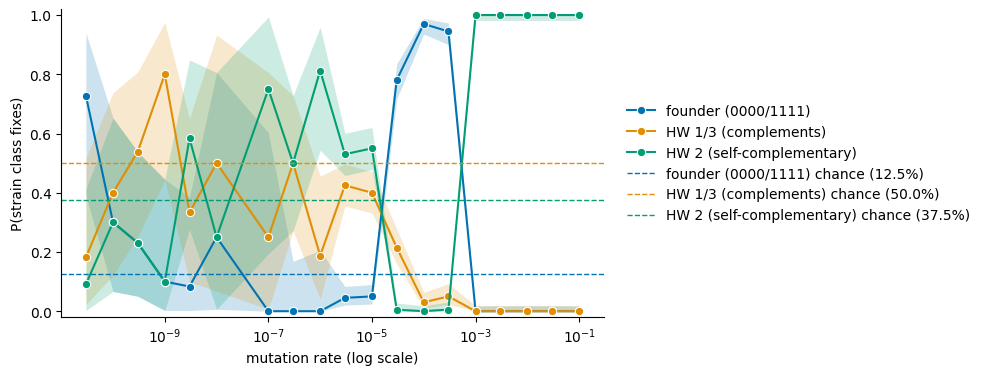

In [ ]:
_groups = [
    "founder (0000/1111)",
    "HW 1/3 (complements)",
    "HW 2 (self-complementary)",
]
_palette = dict(
    zip(_groups, sns.color_palette("colorblind", n_colors=len(_groups))),
)
# Genome-count fraction of the 16 possible 4-site genomes each group
# covers, under a uniform-over-genomes null: founder {0000, 1111}
# (2), HW 1/3 complements (2 * C(4,1) = 8), HW 2 self-complementary
# (C(4,2) = 6).
_chance = {
    "founder (0000/1111)": 2 / 16,
    "HW 1/3 (complements)": 8 / 16,
    "HW 2 (self-complementary)": 6 / 16,
}

with tp.teed(
    sns.lineplot,
    data=summary_df,
    x="mutation_rate",
    y="p",
    hue="group",
    hue_order=_groups,
    palette=_palette,
    marker="o",
    errorbar=None,
    teeplot_outattrs={"a": "founder-vs-hw13-vs-hw2-fixation-prob"},
    teeplot_show=True,
    teeplot_subdir=pathlib.Path(__file__).stem,
) as _ax:
    # Exact-CI band per group (fill_between, not bootstrap).
    for _group in _groups:
        _sub = summary_df[summary_df["group"] == _group].sort_values(
            "mutation_rate",
        )
        _ax.fill_between(
            _sub["mutation_rate"],
            _sub["ci_low"],
            _sub["ci_high"],
            color=_palette[_group],
            alpha=0.2,
            linewidth=0,
        )
    # Color-matched chance-expectation rule per group.
    for _group in _groups:
        _ax.axhline(
            _chance[_group],
            color=_palette[_group],
            linestyle="--",
            linewidth=1.0,
            label=f"{_group} chance ({_chance[_group]:.1%})",
        )
    _ax.set_xscale("log")
    _ax.set_ylim(-0.02, 1.02)
    _ax.set_xlabel("mutation rate (log scale)")
    _ax.set_ylabel("P(strain class fixes)")
    _ax.legend(
        title=None,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=False,
    )
    sns.despine(ax=_ax)
    _ax.figure.set_size_inches(7, 4)

## Probability & 95% CI Table

Per-`mutation_rate` fixation probability with the exact
Clopper-Pearson 95% confidence interval, for both outcome groups.
`n_fixed` / `n_total` are the binomial counts behind each estimate.

In [ ]:
_table_df = (
    summary_df.assign(
        p=summary_df["p"].round(4),
        ci_low=summary_df["ci_low"].round(4),
        ci_high=summary_df["ci_high"].round(4),
        ci_95=summary_df.apply(
            lambda _r: f"[{_r['ci_low']:.3f}, {_r['ci_high']:.3f}]",
            axis=1,
        ),
    )[
        [
            "group",
            "mutation_rate",
            "n_fixed",
            "n_total",
            "p",
            "ci_low",
            "ci_high",
            "ci_95",
        ]
    ]
    .sort_values(["group", "mutation_rate"])
    .reset_index(drop=True)
)

print(_table_df.to_string(index=False))
mo.ui.table(_table_df, selection=None)

                    group  mutation_rate  n_fixed  n_total      p  ci_low  ci_high          ci_95
     HW 1/3 (complements)   3.000000e-11        2       11 0.1818  0.0228   0.5178 [0.023, 0.518]
     HW 1/3 (complements)   1.000000e-10        4       10 0.4000  0.1216   0.7376 [0.122, 0.738]
     HW 1/3 (complements)   3.000000e-10        7       13 0.5385  0.2513   0.8078 [0.251, 0.808]
     HW 1/3 (complements)   1.000000e-09        8       10 0.8000  0.4439   0.9748 [0.444, 0.975]
     HW 1/3 (complements)   3.000000e-09        4       12 0.3333  0.0992   0.6511 [0.099, 0.651]
     HW 1/3 (complements)   1.000000e-08        2        4 0.5000  0.0676   0.9324 [0.068, 0.932]
     HW 1/3 (complements)   1.000000e-07        1        4 0.2500  0.0063   0.8059 [0.006, 0.806]
     HW 1/3 (complements)   3.000000e-07       10       20 0.5000  0.2720   0.7280 [0.272, 0.728]
     HW 1/3 (complements)   1.000000e-06        3       16 0.1875  0.0405   0.4565 [0.040, 0.456]
     HW 1/3 (complem

,group,mutation_rate,n_fixed,n_total,p,ci_low,ci_high,ci_95
0,HW 1/3 (complements),3.000000e-11,2,11,0.1818,0.0228,0.5178,"[0.023, 0.518]"
1,HW 1/3 (complements),1.000000e-10,4,10,0.4000,0.1216,0.7376,"[0.122, 0.738]"
2,HW 1/3 (complements),3.000000e-10,7,13,0.5385,0.2513,0.8078,"[0.251, 0.808]"
3,HW 1/3 (complements),1.000000e-09,8,10,0.8000,0.4439,0.9748,"[0.444, 0.975]"
4,HW 1/3 (complements),3.000000e-09,4,12,0.3333,0.0992,0.6511,"[0.099, 0.651]"
...,...,...,...,...,...,...,...,...
52,founder (0000/1111),1.000000e-03,0,200,0.0000,0.0000,0.0183,"[0.000, 0.018]"
53,founder (0000/1111),3.000000e-03,0,200,0.0000,0.0000,0.0183,"[0.000, 0.018]"
54,founder (0000/1111),1.000000e-02,0,200,0.0000,0.0000,0.0183,"[0.000, 0.018]"
55,founder (0000/1111),3.000000e-02,0,200,0.0000,0.0000,0.0183,"[0.000, 0.018]"
